In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_wine

In [3]:
df, y = load_wine(as_frame=True, return_X_y=True)

# quality를 0과 0 아님으로 구분하는 이진 분류를 진행할거다
y[y == 0] = 0
y[y != 0] = 1

# feature와 y를 합치기
df['quality'] = y
label = df['quality'].value_counts().sort_index()
print(label)
X = df.drop('quality', axis=1).values

quality
0     59
1    119
Name: count, dtype: int64


In [20]:
# 학습 / 테스트 나누기
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y,
)
X_train, X_test

(array([[1.324e+01, 3.980e+00, 2.290e+00, ..., 8.200e-01, 3.000e+00,
         6.800e+02],
        [1.340e+01, 4.600e+00, 2.860e+00, ..., 6.700e-01, 1.920e+00,
         6.300e+02],
        [1.358e+01, 1.660e+00, 2.360e+00, ..., 1.090e+00, 2.880e+00,
         1.515e+03],
        ...,
        [1.103e+01, 1.510e+00, 2.200e+00, ..., 1.710e+00, 2.870e+00,
         4.070e+02],
        [1.243e+01, 1.530e+00, 2.290e+00, ..., 6.900e-01, 2.840e+00,
         3.520e+02],
        [1.339e+01, 1.770e+00, 2.620e+00, ..., 9.200e-01, 3.220e+00,
         1.195e+03]], shape=(124, 13)),
 array([[1.349e+01, 1.660e+00, 2.240e+00, 2.400e+01, 8.700e+01, 1.880e+00,
         1.840e+00, 2.700e-01, 1.030e+00, 3.740e+00, 9.800e-01, 2.780e+00,
         4.720e+02],
        [1.419e+01, 1.590e+00, 2.480e+00, 1.650e+01, 1.080e+02, 3.300e+00,
         3.930e+00, 3.200e-01, 1.860e+00, 8.700e+00, 1.230e+00, 2.820e+00,
         1.680e+03],
        [1.317e+01, 2.590e+00, 2.370e+00, 2.000e+01, 1.200e+02, 1.650e+00,
         6.

In [21]:
# 전처리 Instance 선언
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

# 2. 학습 데이터를 바탕으로 표준화를 위한 사전 작업(평균, 표준편차 등 통계값 계산) 진행
scaler.fit(X_train)

# 3. 통계값을 바탕으로 표준화 진행
X_train_norm = scaler.transform(X_train)
X_train_norm

# 2-3.
X_train_norm = scaler.fit_transform(X_train)
X_train_norm

array([[ 0.3269176 ,  1.38944861, -0.25692334, ..., -0.59273007,
         0.61099477, -0.21646812],
       [ 0.52116873,  1.91630834,  1.79730083, ..., -1.24523831,
        -0.97999141, -0.3793051 ],
       [ 0.73970125, -0.58202649, -0.0046502 , ...,  0.58178477,
         0.43421853,  2.50290939],
       ...,
       [-2.35617611, -0.70949255, -0.58127452, ...,  3.27881884,
         0.41948717, -1.10555802],
       [-0.65647874, -0.69249708, -0.25692334, ..., -1.15823721,
         0.37529311, -1.28467869],
       [ 0.50902803, -0.48855138,  0.93236434, ..., -0.15772457,
         0.93508455,  1.46075274]], shape=(124, 13))

In [24]:
# 테스트 데이터 표준화
X_test_norm = scaler.transform(X_test)
X_test_norm

array([[ 0.63043499, -0.58202649, -0.43711844,  1.3144431 , -0.85846422,
        -0.67735994, -0.16907459, -0.78201158, -1.01967289, -0.54353831,
         0.10327872,  0.28690499, -0.89386995],
       [ 1.48028368, -0.64151065,  0.42781805, -0.90372435,  0.55190854,
         1.66861838,  2.06081704, -0.36367924,  0.42128185,  1.53323255,
         1.19079246,  0.3458304 ,  3.04027142],
       [ 0.24193273,  0.2082631 ,  0.03138882,  0.13142046,  1.35783584,
        -1.05734234, -1.40671779,  1.39331658, -0.27315417,  1.78445484,
        -1.54974216, -1.42193202,  0.3046102 ],
       [ 0.02340021, -0.57352875,  0.8602863 ,  3.08897705,  2.63388739,
         1.66861838,  0.9512059 , -1.28401039,  0.59489086, -0.7068328 ,
         1.53879686,  1.34756245,  0.77683744],
       [-0.19513231, -0.02967355,  0.13950589,  1.3144431 , -0.11969753,
        -1.88339105, -0.96927494, -0.78201158, -1.36689091,  0.27712114,
        -1.28873886, -1.80494721, -0.60727687],
       [ 1.71095689, -0.403574

In [ ]:
# 1. 로지스틱 회귀 모델을 가져온다.
from sklearn.linear_model import LogisticRegression
clf = LogisticRegression(max_iter=1000)

# 2. '.fit()'으로 모델을 학습한다.
clf.fit(X_train, y_train)

# 3. X_test를 입력하여 예측값을 구해온다.
y_pred = clf.predict(X_test)
y_pred, y_test

In [29]:
# 평가: y_pred와 y_test가 얼마나 일치하는가?
from sklearn.metrics import confusion_matrix, classification_report
# 혼동행렬로 정답 예측 결과 비교
print(confusion_matrix(y_test, y_pred))
print()
print(classification_report(y_test, y_pred))

[[18  0]
 [ 1 35]]

              precision    recall  f1-score   support

           0       0.95      1.00      0.97        18
           1       1.00      0.97      0.99        36

    accuracy                           0.98        54
   macro avg       0.97      0.99      0.98        54
weighted avg       0.98      0.98      0.98        54



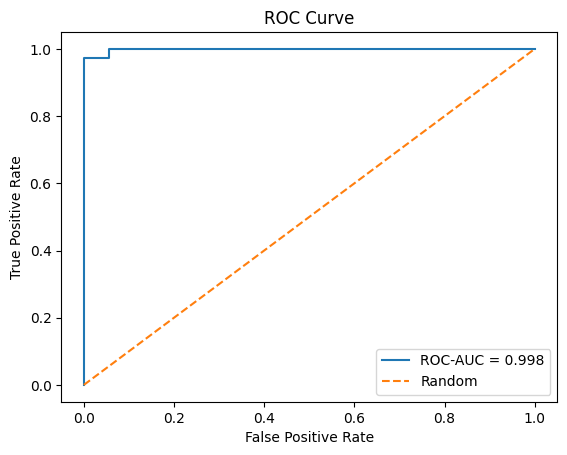

In [34]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

y_score = clf.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_score)
auc = roc_auc_score(y_test, y_score)

# ROC 곡선 시각화 (matplotlib 사용)
plt.plot(fpr, tpr, label=f'ROC-AUC = {auc:.3f}')
plt.plot([0, 1], [0, 1], linestyle='--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()